In [1]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv

In [2]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\2d_missegmentation'

In [3]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [4]:
os.chdir(Path(notebook_dir).parents[3])

In [5]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

import sys  
sys.path.insert(1,stvelo_path)

from pipelines.metrics import *
from pipelines.utils import proportions_nuc_cyto

# Read adatas 

In [6]:
adata_folder_path = os.path.join(os.getcwd(), 'data', 'missegmentation') 

In [7]:
import os
import anndata as ad


# Initialize an empty dictionary to store the AnnData objects
adata_dict = {}

# Loop through all files in the folder
for file_name in os.listdir(adata_folder_path):
    # Check if the file has .h5ad extension
    if file_name.endswith('.h5ad'):
        # Remove the file extension to use as the dictionary key
        key = os.path.splitext(file_name)[0]
        
        # Read the .h5ad file and store it in the dictionary
        adata_dict[key] = scv.read(os.path.join(adata_folder_path, file_name))

# Now, adata_dict contains the .h5ad files with keys as their filenames without extension


In [8]:
adata_800 = {k: v.copy() for k, v in adata_dict.items() if '800' in k}
adata_1000 = {k: v.copy() for k, v in adata_dict.items() if '1000' in k}
adata_1200 = {k: v.copy() for k, v in adata_dict.items() if '1200' in k}

In [15]:
adata_1200['adata_n_c_1200obs_300genes_2dseg_deterministic'].obs.iloc[10:14,:]

,true_t,cyto_missassigned_fraction,nuclei_missassigned_fraction,clear_cytoplasm_proportion,proportion_of_nuclei_included,n_counts,leiden,velocity_self_transition
10,0.14,0.541795,0.4743,0.401123,1.0,618.283602,4,0.109679
11,0.14,0.567500,0.4679,0.356593,1.0,642.982017,4,0.061374
12,0.16,0.574457,0.4778,0.353942,1.0,666.816067,4,0.045476
13,0.18,0.587227,0.4784,0.336276,1.0,741.472920,4,0.058438


In [13]:
adata_1200['adata_n_c_1200obs_300genes_2dseg_deterministic'].var.sort_values('true_t_')

,true_t_,true_alpha,true_beta,true_nu,true_gamma,true_scaling,n_cells,velocity_gamma,velocity_qreg_ratio,velocity_r2,velocity_genes
99,1.316788,1.949364,0.751723,0.302282,0.702613,1.0,1154,9.927080,9.927080,0.600943,True
283,1.432263,7.732847,0.602198,0.422925,0.286603,1.0,1178,3.974182,3.974182,0.312843,True
166,1.432263,8.557259,0.697087,0.945475,0.168583,1.0,1186,2.754882,2.754882,0.331378,True
262,1.519849,1.249212,0.318935,0.222625,0.250227,1.0,1199,5.538090,5.538090,-0.271160,False
126,1.554731,2.114145,0.551246,0.224528,0.349160,1.0,1193,5.800878,5.800878,0.212534,True
...,...,...,...,...,...,...,...,...,...,...,...
20,18.313895,9.202675,0.505448,0.441037,0.112753,1.0,1196,2.500060,2.500060,0.175585,True
286,18.415173,7.577253,0.808133,1.031557,0.269654,1.0,1198,2.522577,2.522577,0.215652,True
52,18.546184,3.067915,0.947848,0.428230,0.601564,1.0,1198,5.621071,5.621071,0.326108,True
210,18.577083,4.462789,1.023200,0.390855,0.695280,1.0,1200,6.530237,6.530237,0.415729,True


In [9]:
import numpy as np
import pandas as pd

def pearson_correlation_matrices(matrix1, matrix2, mode='by_row'):
    """
    Computes Pearson correlation between two matrices either by row or by column.

    Parameters:
    - matrix1, matrix2: Two matrices (NumPy arrays or DataFrames) with the same shape.
    - mode: 'by_row' or 'by_column' to specify the direction for calculating correlations.

    Returns:
    - correlations: List of Pearson correlation coefficients for each row or column.
    """
    # Ensure matrices are in the right shape and format (convert to numpy if DataFrame)
    if isinstance(matrix1, pd.DataFrame):
        matrix1 = matrix1.values
    if isinstance(matrix2, pd.DataFrame):
        matrix2 = matrix2.values

    # Check if shapes are compatible
    if matrix1.shape != matrix2.shape:
        raise ValueError("Both matrices must have the same shape.")

    # Initialize list to store correlation coefficients
    correlations = []

    # Correlation by row (across columns)
    if mode == 'by_row':
        for i in range(matrix1.shape[0]):  # Loop through each row
            row1 = matrix1[i, :]
            row2 = matrix2[i, :]
            # Mask NaNs if present
            mask = ~np.isnan(row1) & ~np.isnan(row2)
            if np.sum(mask) > 0:
                corr = np.corrcoef(row1[mask], row2[mask])[0, 1]
                correlations.append(corr)
            else:
                correlations.append(np.nan)  # Append NaN if no valid data

    # Correlation by column (across rows)
    elif mode == 'by_column':
        for j in range(matrix1.shape[1]):  # Loop through each column
            col1 = matrix1[:, j]
            col2 = matrix2[:, j]
            # Mask NaNs if present
            mask = ~np.isnan(col1) & ~np.isnan(col2)
            if np.sum(mask) > 0:
                corr = np.corrcoef(col1[mask], col2[mask])[0, 1]
                correlations.append(corr)
            else:
                correlations.append(np.nan)  # Append NaN if no valid data

    else:
        raise ValueError("Invalid mode. Use 'by_row' or 'by_column'.")

    return correlations


<Axes: >

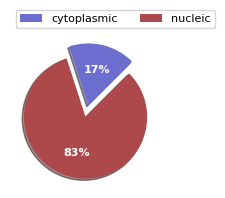

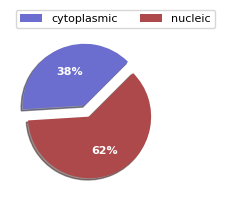

In [ ]:
proportions_nuc_cyto(adata_800['adata_n_c_800obs_300genes_2dseg_deterministic'])
proportions_nuc_cyto(adata_800['adata_n_c_800obs_300genes_deterministic'])

# Umaps 

In [20]:
import matplotlib.pyplot as plt 

In [27]:
import matplotlib.pyplot as plt
import scvelo as scv

def plot_velocity_embedding_streams(adata_dict, n_obs='800', n_var='300', color_option='true_t'):
    """
    Plots velocity embedding streams for an AnnData dictionary with a specified color option.

    Parameters:
    - adata_dict (dict): Dictionary with AnnData objects. Keys should follow the pattern 
                         'adata_n_c_{n_obs}obs_{n_var}genes_{velocity_type}' for initial data and
                         'adata_n_c_{n_obs}obs_{n_var}genes_2dseg_{velocity_type}' for data with missegmentation.
    - color_option (str): Column name in AnnData.obs to color the plots. Default is 'true_t'.
    """
    # Create a figure with 2 rows and 4 columns of subplots
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # Adjust figsize as needed

    # List of velocity types and corresponding column labels
    velocity_types = ['deterministic', 'stochastic', 'dynamical', 'velovi']
    column_labels = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']

    # Row titles
    row_titles = ['Initial', '2D Missegmentation']

    # Adjust subplot parameters to make room for titles
    plt.subplots_adjust(top=0.90, left=0.10)

    # Loop over each data type and plot the corresponding subplots
    for i, (data_suffix, row_title) in enumerate(zip(['', '_2dseg'], row_titles)):
        for j, (velocity_type, col_label) in enumerate(zip(velocity_types, column_labels)):
            # Construct the adata key based on whether it's initial or with missegmentation
            adata_key = f'adata_n_c_{n_obs}obs_{n_var}genes{data_suffix}_{velocity_type}'
            if adata_key in adata_dict:
                scv.pl.velocity_embedding_stream(
                    adata_dict[adata_key],
                    basis='umap',
                    color=color_option,
                    ax=axes[i, j],
                    show=False,
                    title=''  # Titles are added separately
                )
            else:
                axes[i, j].axis('off')  # Hide axes if data is not available

            # Turn off axis labels to reduce clutter
            axes[i, j].set_xlabel('')
            axes[i, j].set_ylabel('')

    # Add column titles (velocity models)
    for j, col_label in enumerate(column_labels):
        axes[0, j].set_title(col_label, fontsize=14)

    # Add row titles (data types)
    for i, row_title in enumerate(row_titles):
        # Place text in the middle of the row using fig.text
        fig.text(
            0.06,  # Adjust horizontal position as needed
            (0.75 - i * 0.5),  # Adjust vertical position based on the number of rows
            row_title,
            ha='center',
            va='center',
            rotation='vertical',
            fontsize=14
        )

    # Add a main title for the entire figure
    fig.suptitle('Effect of 2D Segmentation on Velocity Embedding Streams', fontsize=16, y=0.98)

    # Adjust layout to prevent overlap
    plt.tight_layout(rect=[0.07, 0.05, 1, 0.95])

    # Show the plot
    plt.show()


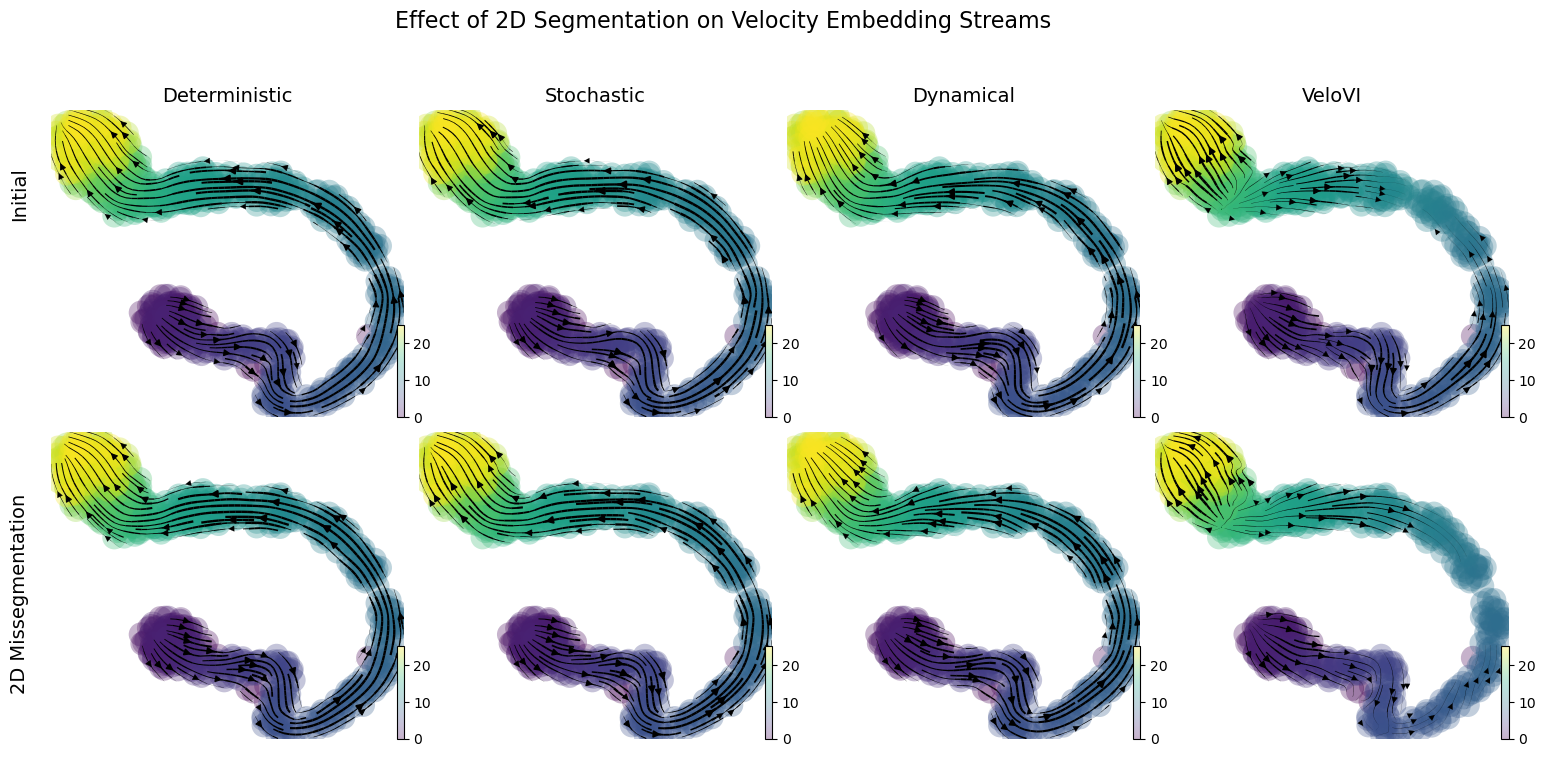

In [28]:
plot_velocity_embedding_streams(adata_dict=adata_800, n_obs='800', n_var='300', color_option='true_t')

# Metrics 

## Velocity Confidence


- Confidence metric measures the mean velocity consistency by calculating the pearson correlation between a cell and its neighbours. Let $v(x_j)$ be the velocity of cell $x_j$. Confidence $c_j$ is given by;

$$c_j = \frac{1}{k} \sum_{x \in \mathit{N_k(x_j)} } corr(v(x_j),v(x))$$

where $\mathit{N_k(x_j)}$ is the k-neighbours of $x_j$ in KNN graph.

In [29]:
import scvelo as scv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_velocity_confidences(adatas):
    """
    Computes velocity confidences for each AnnData object in the dictionary and plots them using a violin plot.

    Parameters:
    - adatas (dict): Dictionary where keys are in the format 'adata_n_c_obs_genes_[2dseg]_velocitytype',
                     and values are AnnData objects.

    The keys should follow this format:
    - 'adata_n_c_800obs_300genes_deterministic'
    - 'adata_n_c_800obs_300genes_2dseg_deterministic'
    """

    # Initialize an empty list to collect data for plotting
    plot_data = []

    # Loop through each AnnData object in the dictionary
    for key, adata in adatas.items():
        # Compute velocity confidence if not already computed
        if 'velocity_confidence' not in adata.obs:
            scv.tl.velocity_confidence(adata)

        # Extract velocity confidences from adata.obs
        velocity_confidence = adata.obs['velocity_confidence'].values

        # Parse the key to extract metadata
        # Key format: 'adata_n_c_obs_genes_[2dseg]_velocitytype'
        parts = key.split('_')
        
        # Identify if '2dseg' is present
        if '2dseg' in parts:
            has_2dseg = True
            parts.remove('2dseg')  # Remove '2dseg' to keep indexing consistent
        else:
            has_2dseg = False

        # Extract observation count (e.g., '800obs')
        obs_idx = parts.index('c') + 1  # After 'n_c'
        obs_count = parts[obs_idx]  # e.g., '800obs'
        # Remove 'obs' to get the numeric value
        obs_count_value = int(obs_count.replace('obs', ''))

        # Extract velocity model type (e.g., 'deterministic', 'stochastic', etc.)
        velocity_type = parts[-1]

        # Map velocity_type to capitalized labels
        velocity_type_map = {
            'deterministic': 'Deterministic',
            'stochastic': 'Stochastic',
            'dynamical': 'Dynamical',
            'velovi': 'VeloVI'
        }
        velocity_type_label = velocity_type_map.get(velocity_type, velocity_type.capitalize())

        # Determine 'data_segmentation' status
        data_segmentation = '2D Missegmentation' if has_2dseg else 'Standard'

        # Create a DataFrame for this adata
        df = pd.DataFrame({
            'velocity_confidence': velocity_confidence,
            'velocity_type': velocity_type_label,
            'obs_count': obs_count_value,
            'data_segmentation': data_segmentation
        })

        # Append to the list
        plot_data.append(df)

    # Concatenate all DataFrames into one
    plot_df = pd.concat(plot_data, ignore_index=True)

    # Define the order of velocity types
    velocity_type_order = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']

    # Map 'velocity_type' to categorical type with specified order
    plot_df['velocity_type'] = pd.Categorical(
        plot_df['velocity_type'],
        categories=velocity_type_order,
        ordered=True
    )

    # Map 'data_segmentation' to categorical type with specified order
    plot_df['data_segmentation'] = pd.Categorical(
        plot_df['data_segmentation'],
        categories=['Standard', '2D Missegmentation'],
        ordered=True
    )

    # Sort observation counts for consistent plotting
    obs_count_order = sorted(plot_df['obs_count'].unique())
    # Map 'obs_count' to categorical type with specified order
    plot_df['obs_count'] = pd.Categorical(
        plot_df['obs_count'],
        categories=obs_count_order,
        ordered=True
    )

    # Now, plot using seaborn catplot
    g = sns.catplot(
        x='velocity_type',
        y='velocity_confidence',
        hue='data_segmentation',
        col='obs_count',
        data=plot_df,
        kind='violin',
        order=velocity_type_order,
        hue_order=['Standard', '2D Missegmentation'],
        split=False,
        scale='width',
        inner='quartile',
        height=6,
        aspect=1
    )

    g.set_axis_labels("RNA Velocity Model", "Velocity Confidence")
    g.set_titles("Observation Count: {col_name}")
    g.fig.subplots_adjust(top=0.85)
    g.fig.suptitle('Velocity Confidence by RNA Velocity Model and Data Segmentation')

    plt.show()


--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length'

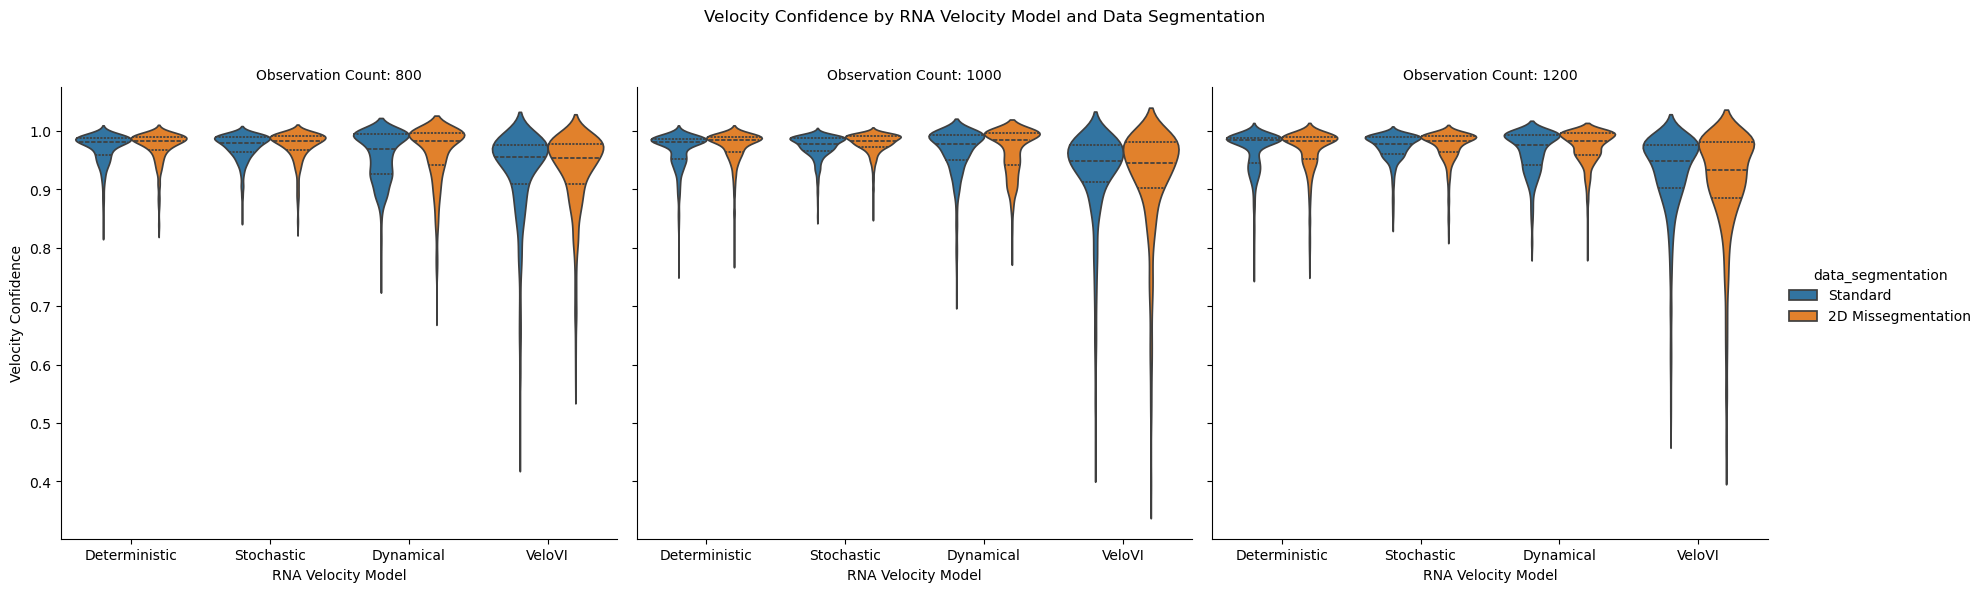

In [30]:
plot_velocity_confidences(adata_dict)

## velocity Correlations (by_gene)

In [31]:
import scvelo as scv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import ma

def compute_velocity_correlations(adatas, mode='by_gene'):
    """
    Computes the correlation between velocity matrices of the same velocity type but different data types (n_c vs s_u).

    Parameters:
    - adatas (dict): Dictionary where keys are in the format 'adata_type_obs_genes_velocitytype',
                     and values are AnnData objects.
    - mode (str): 'by_gene' or 'by_cell' to specify the axis along which to compute the correlations.

    Returns:
    - correlations (dict): A dictionary with velocity types as keys and lists of correlation coefficients as values.
    """

    # Collect all unique velocity types
    velocity_types = set()
    for key in adatas.keys():
        parts = key.split('_')
        velocity_type = parts[-1]  # e.g., 'deterministic', 'stochastic', 'dynamical', 'velovi'
        velocity_types.add(velocity_type)

    correlations = {}  # Dictionary to store correlations for each velocity type

    for velocity_type in velocity_types:
        print(velocity_type)
        # Find the corresponding AnnData objects for n_c and s_u
        key_n_c = None
        key_s_u = None
        for key in adatas.keys():
            if key.endswith(velocity_type):
                if '2dseg' in key:
                    key_2d = key
                else:
                    key_s = key
        if key_2d and key_s:
            adata_2d = adatas[key_2d]
            adata_s = adatas[key_s]

            # Ensure that the velocity matrices are computed
            if 'velocity' not in adata_2d.layers or 'velocity' not in adata_s.layers:
                print(f"Velocity not found in {key_n_c} or {key_s_u}. Skipping.")
                continue

            # Extract the velocity matrices
            velo_n_c = pd.DataFrame(
                adata_2d.layers['velocity'], 
                index=adata_2d.obs_names, 
                columns=adata_2d.var_names
            )
            velo_s_u = pd.DataFrame(
                adata_s.layers['velocity'], 
                index=adata_s.obs_names, 
                columns=adata_s.var_names
            )

            # Ensure that the DataFrames are aligned
            # velo_n_c = velo_n_c.sort_index().sort_index(axis=1)
            # velo_s_u = velo_s_u.sort_index().sort_index(axis=1)

            # Compute correlations
            if mode == 'by_cell':
                # Compute correlation by cell (across genes)
                cross_corrs = []
                for i in velo_n_c.index:
                    v1 = velo_n_c.loc[i].values
                    v2 = velo_s_u.loc[i].values
                    # Handle NaNs
                    mask = ~np.isnan(v1) & ~np.isnan(v2)
                    if np.sum(mask) > 0:
                        corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                        cross_corrs.append(corr)
                correlations[velocity_type] = cross_corrs
            elif mode == 'by_gene':
                # Compute correlation by gene (across cells)
                cross_corrs = []
                for gene in velo_n_c.columns:
                    v1 = velo_n_c[gene].values
                    v2 = velo_s_u[gene].values
                    # Handle NaNs
                    mask = ~np.isnan(v1) & ~np.isnan(v2)
                    if np.sum(mask) > 0:
                        corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                        cross_corrs.append(corr)
                correlations[velocity_type] = cross_corrs
            else:
                print(f"Unknown mode: {mode}. Use 'by_gene' or 'by_cell'.")
                return None
        else:
            print(f"Could not find matching n_c and s_u AnnData objects for velocity type {velocity_type}.")
    return correlations


In [32]:
def plot_velocity_correlations(correlations):
    """
    Plots box plots of the correlations calculated for each velocity type.

    Parameters:
    - correlations (dict): Dictionary with velocity types as keys and lists of correlation coefficients as values.
    """
    # Prepare the data for plotting
    plot_data = []
    for velocity_type, corr_values in correlations.items():
        # Map velocity_type to capitalized labels
        velocity_type_map = {
            'deterministic': 'Deterministic',
            'stochastic': 'Stochastic',
            'dynamical': 'Dynamical',
            'velovi': 'VeloVI'
        }
        velocity_type_label = velocity_type_map.get(velocity_type, velocity_type.capitalize())

        df = pd.DataFrame({
            'Correlation': corr_values,
            'Velocity Type': velocity_type_label
        })
        plot_data.append(df)

    # Concatenate all DataFrames
    plot_df = pd.concat(plot_data, ignore_index=True)

    # Define the order of velocity types
    velocity_type_order = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        x='Velocity Type',
        y='Correlation',
        data=plot_df,
        order=velocity_type_order,
        palette='Set2'
    )
    sns.stripplot(
        x='Velocity Type',
        y='Correlation',
        data=plot_df,
        order=velocity_type_order,
        color='black',
        size=3,
        jitter=True,
        alpha=0.5
    )
    plt.title('Correlation between Original and missegmentation added Velocity Matrices by Velocity Model')
    plt.xlabel('Velocity Model')
    plt.ylabel('Correlation Coefficient')
    plt.tight_layout()
    plt.show()


In [33]:
cor = compute_velocity_correlations(adata_800)

velovi
stochastic
deterministic
dynamical


In [34]:
len(cor['dynamical'])

168

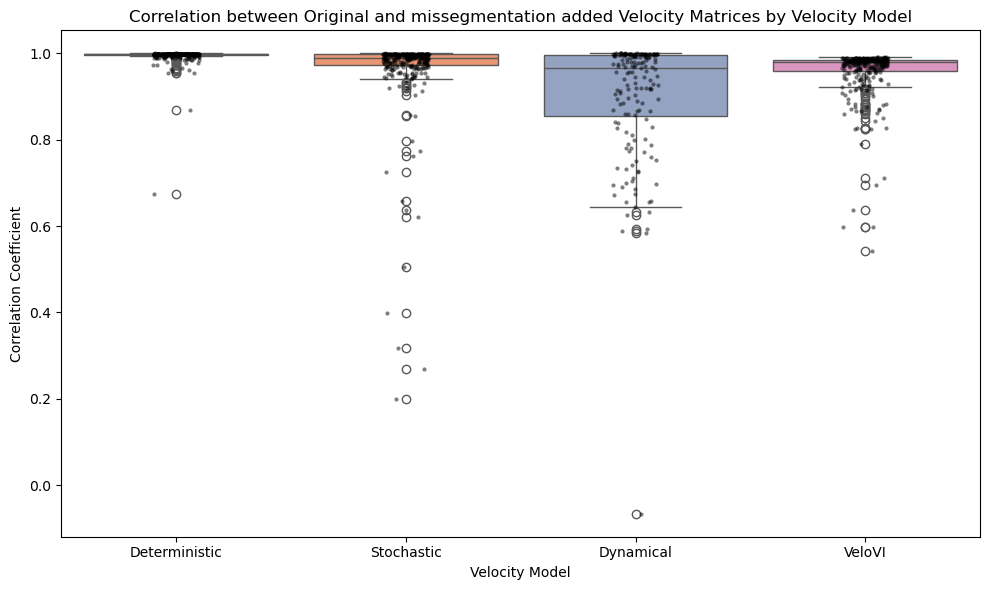

In [35]:
plot_velocity_correlations(cor)

In [235]:
pd.set_option('display.max_rows', 20)

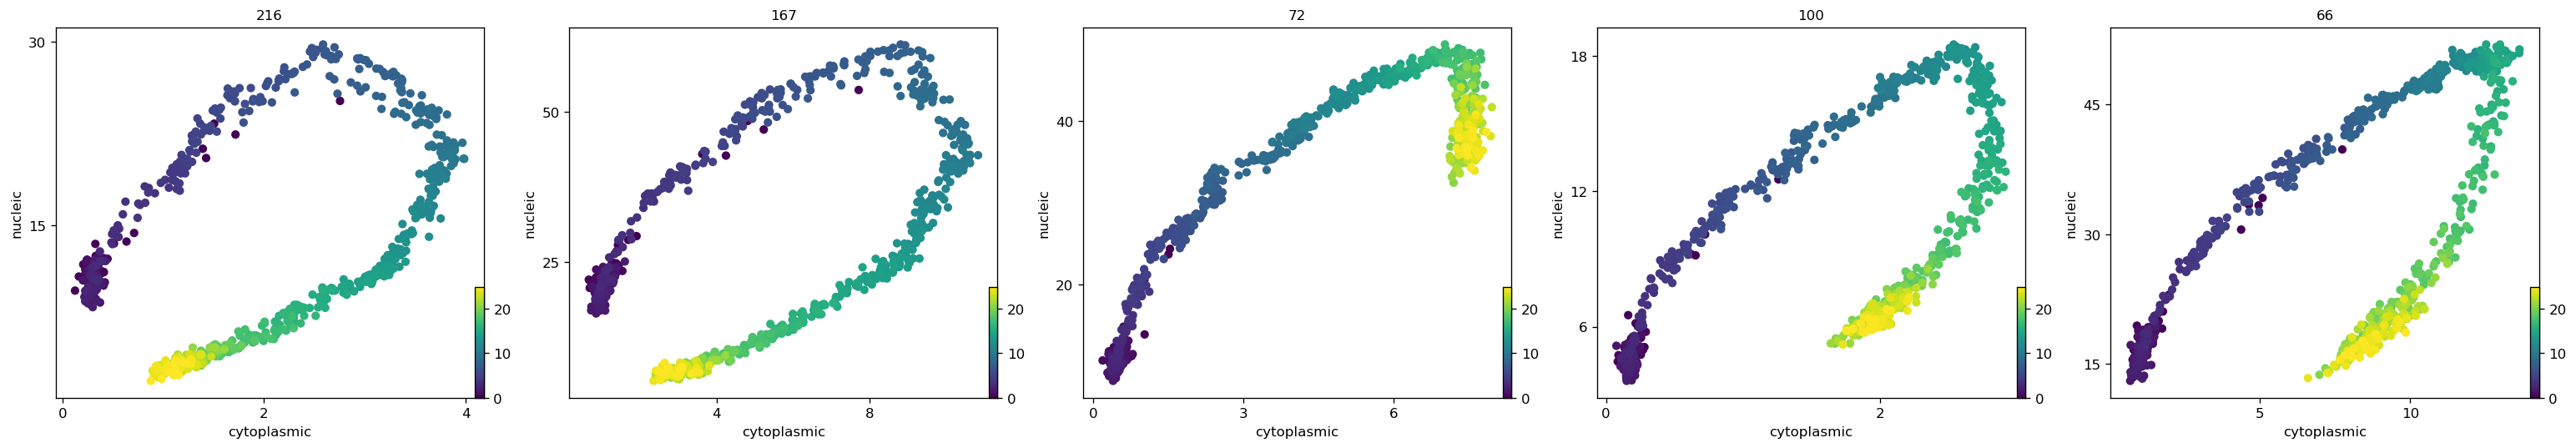

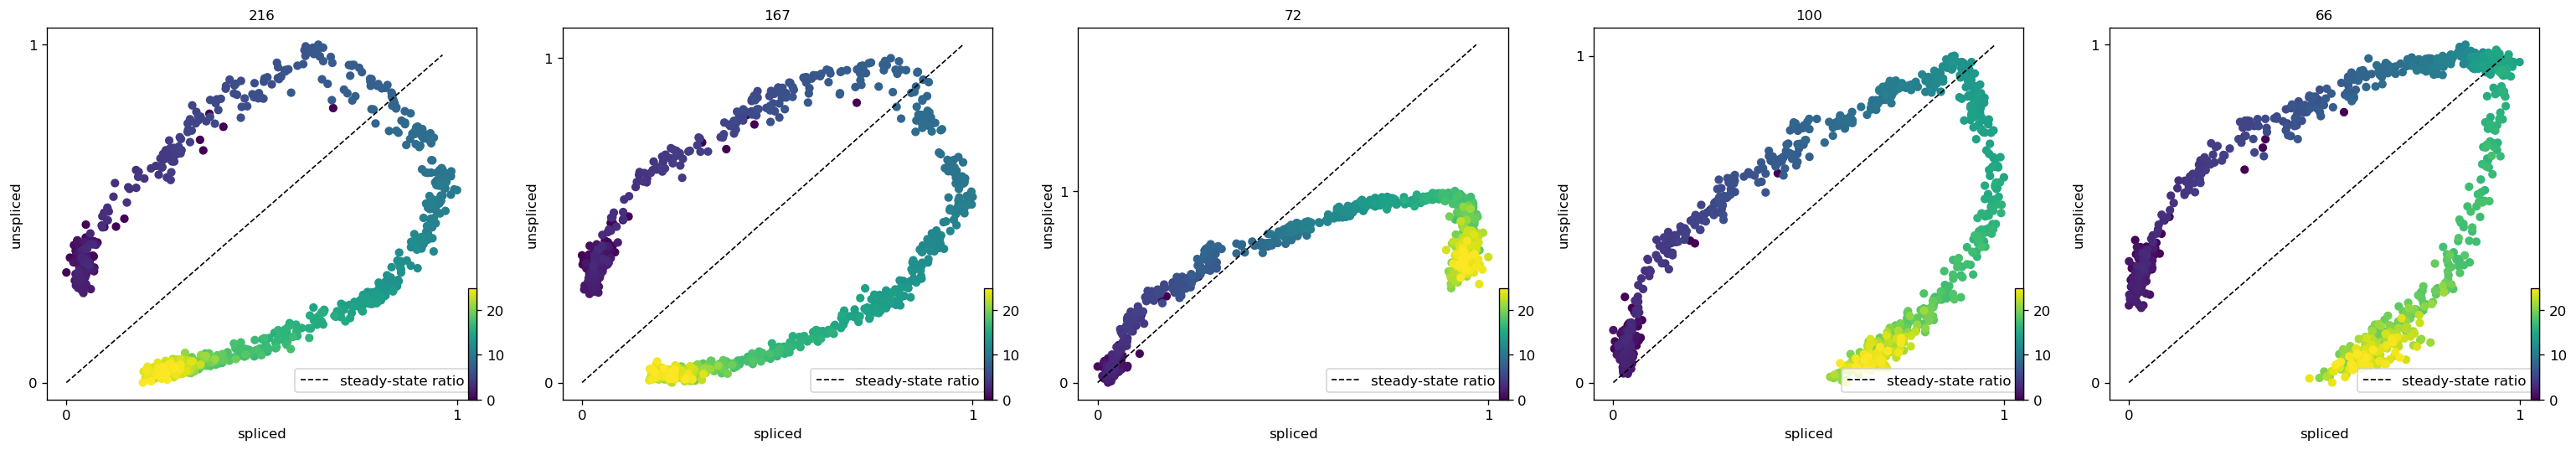

In [37]:
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_2dseg_dynamical'],color="true_t", basis=['216','167','72','100','66'], ncols=5, frameon=True,dpi=120, xlabel='cytoplasmic', ylabel='nucleic', vkey='velocity')
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_velovi'],color="true_t", basis=['216','167','72','100','66'], ncols=5, frameon=True,dpi=120, vkey='velocity')

## Velocity Correlation by Cell

In [38]:
cor = compute_velocity_correlations(adata_800,mode='by_cell')

velovi
stochastic
deterministic
dynamical


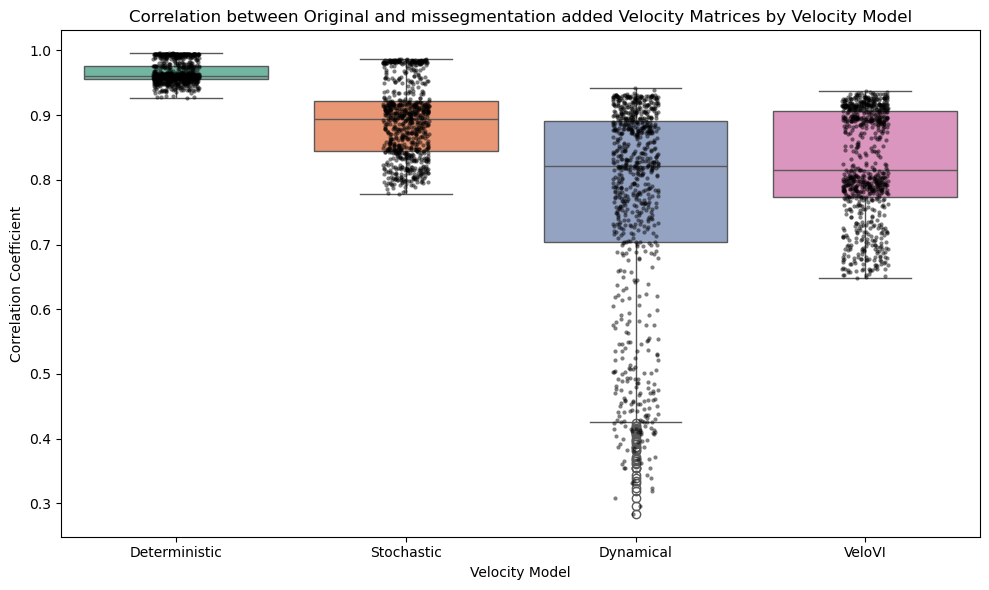

In [39]:
plot_velocity_correlations(cor)

In [70]:
corr_df_cell = pd.DataFrame(cor)
# corr_df_gene.reset_index(inplace=True)
true_t = list(adata_dict['adata_n_c_800obs_300genes_dynamical'].obs['true_t'])
leiden = list(adata_dict['adata_n_c_800obs_300genes_dynamical'].obs['leiden'])
corr_df_cell['true_t'] = true_t
corr_df_cell['leiden'] = leiden

In [71]:
corr_df_cell.sort_values('dynamical')

,velovi,stochastic,dynamical,deterministic,true_t,leiden
728,0.788567,0.915610,0.284134,0.964242,22.63,0
663,0.784877,0.911153,0.295979,0.962478,20.51,0
795,0.801963,0.907492,0.308480,0.963644,24.90,0
736,0.753856,0.914742,0.319420,0.960828,22.80,0
792,0.773951,0.916766,0.323185,0.964198,24.81,0
...,...,...,...,...,...,...
133,0.693286,0.963695,0.931587,0.989550,3.47,1
3,0.862723,0.925502,0.932203,0.978786,0.04,6
4,0.892777,0.921563,0.934635,0.981054,0.08,7
1,0.800183,0.936832,0.938480,0.980697,0.01,7


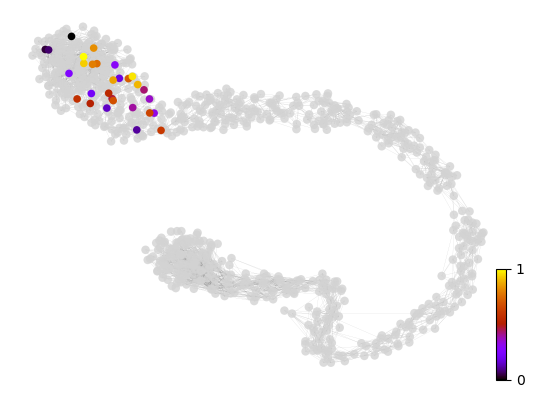

In [72]:
x, y = scv.utils.get_cell_transitions(adata_dict['adata_n_c_800obs_300genes_dynamical'], basis='umap', starting_cell=728)
ax = scv.pl.velocity_graph(adata_dict['adata_n_c_800obs_300genes_dynamical'], c='lightgrey', edge_width=.05, show=False)
ax = scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_dynamical'], x=x, y=y, s=120, c='ascending', cmap='gnuplot', ax=ax)

In [40]:
import pandas as pd
import numpy as np

def compute_velocity_correlations(adatas, mode='by_gene'):
    """
    Computes pairwise correlations between velocity matrices of AnnData objects
    that have the same observation counts, including '2dseg' and 'original' data types.

    Parameters:
    - adatas (dict): Dictionary where keys are in the format
                     'adata_n_c_obs_genes_2dseg_velocitytype' or
                     'adata_n_c_obs_genes_velocitytype', and values are AnnData objects.
    - mode (str): 'by_gene' or 'by_cell' to specify the axis along which to compute the correlations.

    Returns:
    - correlations (dict): A nested dictionary where each observation count is a key, and the value is
                           another dictionary with model identifiers as keys and lists of correlation coefficients.
                           Each correlation list contains all pairwise correlations (not averaged).
    - mean_correlations (dict): A nested dictionary with observation counts as keys and DataFrames of mean pairwise
                                correlations between models as values.
    """

    # Collect all unique observation counts
    obs_counts = set()
    for key in adatas.keys():
        parts = key.split('_')
        obs_part = parts[3]  # e.g., '800obs'
        obs_count = obs_part.replace('obs', '')
        obs_counts.add(obs_count)

    # Initialize dictionaries to store correlations
    correlations = {}        # Store all individual correlations
    mean_correlations = {}   # Store mean correlations in a matrix

    for obs_count in obs_counts:
        # Find all AnnData objects with the same observation count
        adata_keys = [key for key in adatas.keys() if f'_{obs_count}obs_' in key]
        adata_dict = {key: adatas[key] for key in adata_keys}

        # Extract model identifiers for labeling (combining data_type and velocity_type)
        model_identifiers = []
        for key in adata_keys:
            parts = key.split('_')
            # Check if '2dseg' is in parts
            if '2dseg' in parts:
                data_type = '2dseg'
                velocity_type = parts[-1]
            else:
                data_type = 'original'
                velocity_type = parts[-1]
            model_id = f"{data_type}_{velocity_type}"
            model_identifiers.append(model_id)

        # Create a mapping from key to model_id for later use
        key_to_model_id = {}
        for key in adata_keys:
            parts = key.split('_')
            if '2dseg' in parts:
                data_type = '2dseg'
                velocity_type = parts[-1]
            else:
                data_type = 'original'
                velocity_type = parts[-1]
            model_id = f"{data_type}_{velocity_type}"
            key_to_model_id[key] = model_id

        # Initialize DataFrame to store mean correlations between models
        corr_matrix = pd.DataFrame(index=model_identifiers, columns=model_identifiers, dtype=float)
        
        # Dictionary to store all pairwise correlations for this obs_count
        all_corrs_for_obs = {model_id: {} for model_id in model_identifiers}

        # Compute pairwise correlations between models
        for i, key1 in enumerate(adata_keys):
            adata1 = adatas[key1]
            if 'velocity' not in adata1.layers:
                print(f"Velocity not found in {key1}. Skipping.")
                continue

            # Extract velocity matrix
            velo1 = pd.DataFrame(
                adata1.layers['velocity'],
                index=adata1.obs_names,
                columns=adata1.var_names
            )

            for j, key2 in enumerate(adata_keys[i:], i):
                adata2 = adatas[key2]
                if 'velocity' not in adata2.layers:
                    print(f"Velocity not found in {key2}. Skipping.")
                    continue

                # Extract velocity matrix
                velo2 = pd.DataFrame(
                    adata2.layers['velocity'],
                    index=adata2.obs_names,
                    columns=adata2.var_names
                )

                # Ensure DataFrames are aligned
                velo1_aligned, velo2_aligned = velo1.align(velo2, join='inner', axis=0)
                velo1_aligned, velo2_aligned = velo1_aligned.align(velo2_aligned, join='inner', axis=1)

                # Compute correlations
                cross_corrs = []
                if mode == 'by_cell':
                    # Compute correlation by cell (across genes)
                    for idx in velo1_aligned.index:
                        v1 = velo1_aligned.loc[idx].values
                        v2 = velo2_aligned.loc[idx].values
                        mask = ~np.isnan(v1) & ~np.isnan(v2)
                        if np.sum(mask) > 0:
                            corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                            # corr = np.corrcoef(v1, v2)[0, 1]
                            cross_corrs.append(corr)

                elif mode == 'by_gene':
                    # Compute correlation by gene (across cells)
                    for col in velo1_aligned.columns:
                        v1 = velo1_aligned[col].values
                        v2 = velo2_aligned[col].values
                        mask = ~np.isnan(v1) & ~np.isnan(v2)
                        if np.sum(mask) > 0:
                            corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                            # corr = np.corrcoef(v1, v2)[0, 1]
                            cross_corrs.append(corr)
                else:
                    print(f"Unknown mode: {mode}. Use 'by_gene' or 'by_cell'.")
                    return None

                # Store all individual correlations
                model_id1 = key_to_model_id[key1]
                model_id2 = key_to_model_id[key2]
                all_corrs_for_obs[model_id1][model_id2] = cross_corrs
                all_corrs_for_obs[model_id2][model_id1] = cross_corrs  # Symmetric matrix

                # Calculate and store mean correlation for the pair
                mean_corr = np.nanmean(cross_corrs)
                corr_matrix.loc[model_id1, model_id2] = mean_corr
                corr_matrix.loc[model_id2, model_id1] = mean_corr  # Symmetric matrix

        correlations[obs_count] = all_corrs_for_obs
        mean_correlations[obs_count] = corr_matrix

    return correlations, mean_correlations


In [41]:
corr, mean_corr = compute_velocity_correlations(adata_dict,mode='by_gene')

In [42]:
def get_lowest_correlated_genes(correlations, obs_count, model1, model2, n=5):
    """
    Retrieves the gene names with the lowest correlations between two models.

    Parameters:
    - correlations (dict): The dictionary containing all correlation values.
    - obs_count (str): The observation count (e.g., '800', '1000', or '1200').
    - model1 (str): The first model to compare (e.g., 'deterministic').
    - model2 (str): The second model to compare (e.g., 'stochastic').
    - n (int): The number of lowest correlations to retrieve.

    Returns:
    - list of tuples: Each tuple contains a gene index and its correlation value.
    """
    # Extract the correlation list for the specified models and observation count
    correlation_list = correlations[obs_count][model1][model2]

    # Sort correlations and get the indices of the n lowest values
    lowest_indices = np.argsort(correlation_list)[:n]
    lowest_correlations = [(i, correlation_list[i]) for i in lowest_indices]

    return lowest_correlations

In [43]:
get_lowest_correlated_genes(corr,'800','2dseg_velovi','original_velovi')

[(128, 0.5415057812194333),
 (118, 0.5966126116392336),
 (173, 0.5987473716270877),
 (283, 0.6370462879375832),
 (126, 0.6950560987508225)]

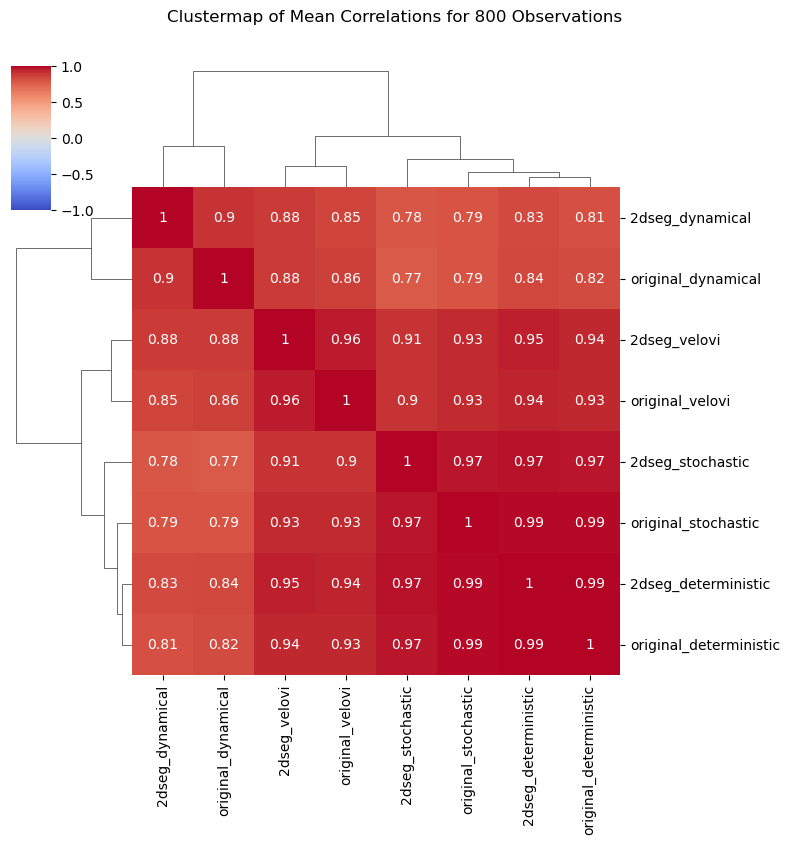

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the mean correlation matrix for observation count '800'
corr_matrix_800 = mean_corr['800']

# Convert the DataFrame to numeric values
corr_matrix_800_numeric = corr_matrix_800.astype(float)

# Plot the clustermap
g = sns.clustermap(
    corr_matrix_800_numeric,
    cmap='coolwarm',
    annot=True,
    vmin=-1,
    vmax=1,
    figsize=(8, 8)
)

# Add a title to the clustermap
g.fig.suptitle('Clustermap of Mean Correlations for 800 Observations', y=1.05)

# Show the plot
plt.show()


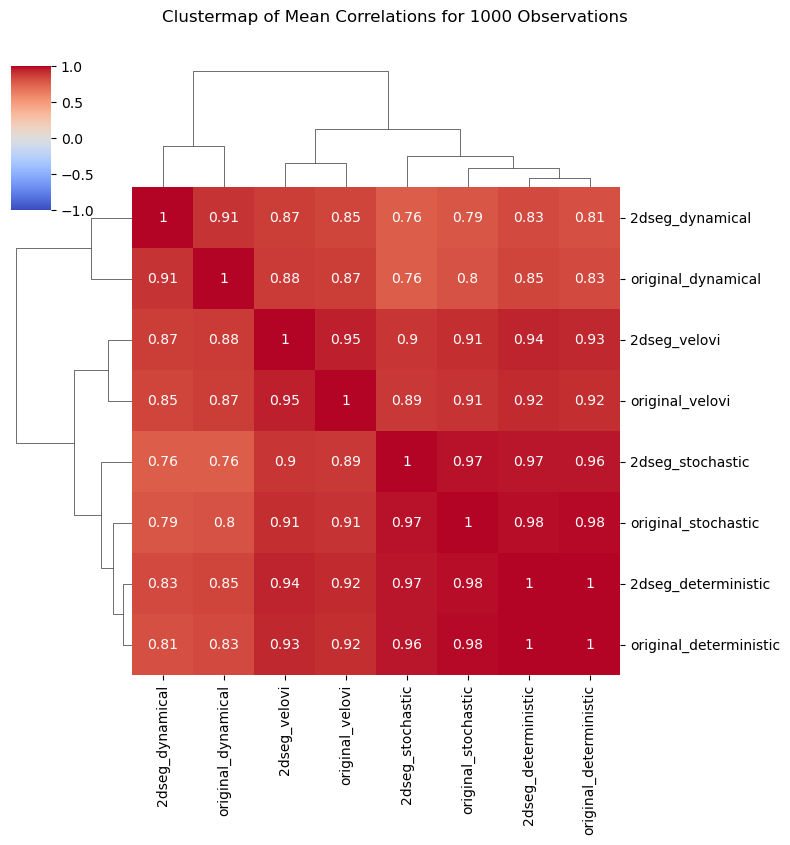

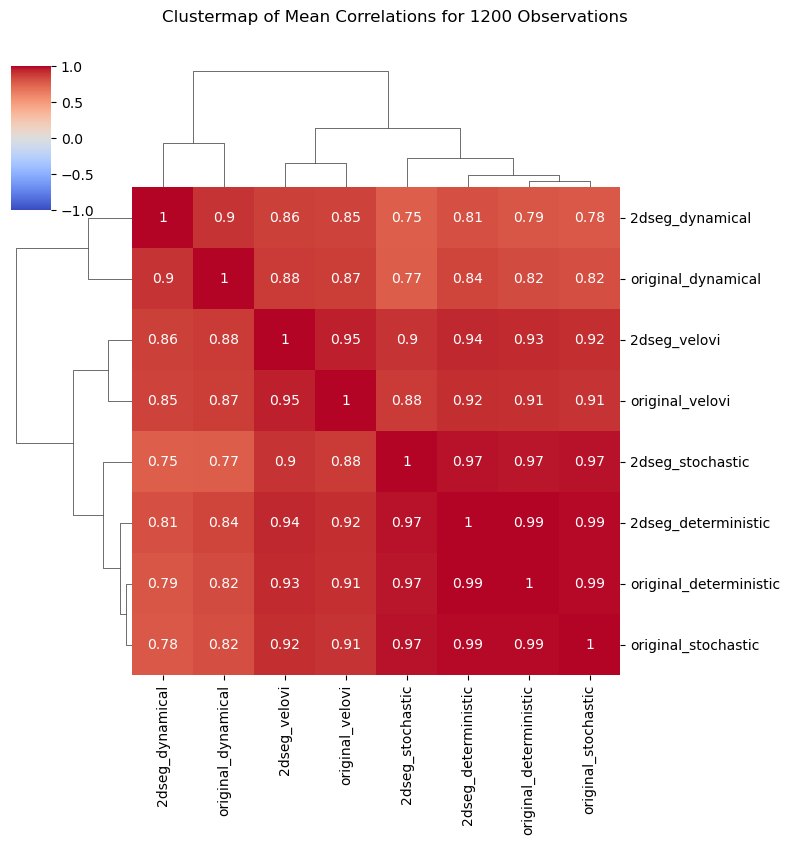

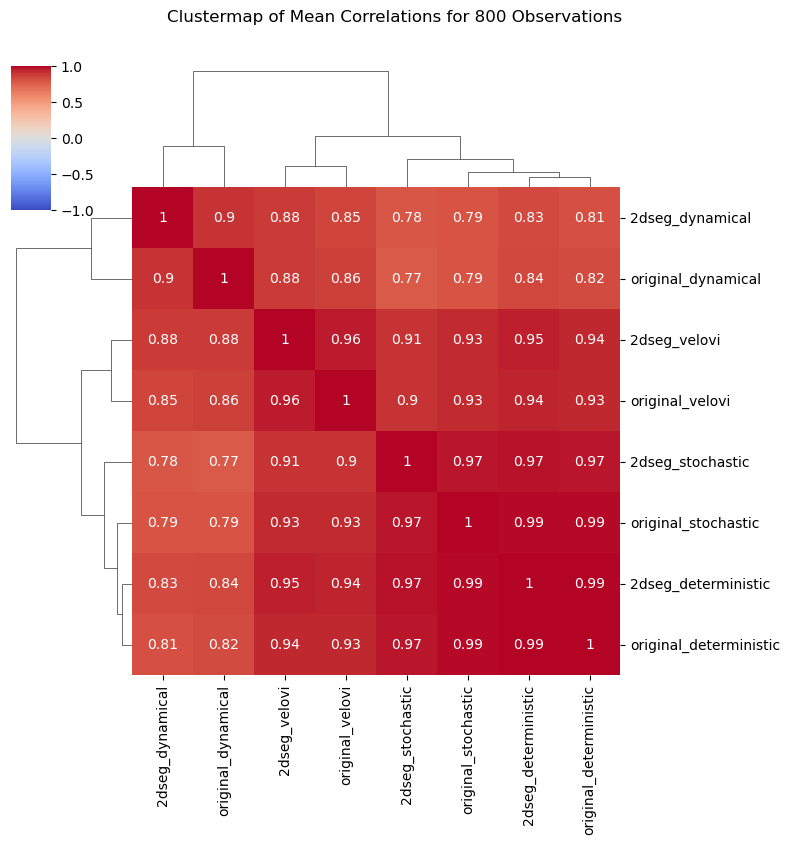

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

for obs_count in sorted(mean_corr.keys()):
    corr_matrix = mean_corr[obs_count]
    corr_matrix_numeric = corr_matrix.astype(float)
    
    g = sns.clustermap(
        corr_matrix_numeric,
        cmap='coolwarm',
        annot=True,
        vmin=-1,
        vmax=1,
        figsize=(8, 8)
    )
    g.fig.suptitle(f'Clustermap of Mean Correlations for {obs_count} Observations', y=1.05)
    plt.show()


In [96]:
corr_cell, mean_corr_cell = compute_velocity_correlations(adata_dict,mode='by_cell')

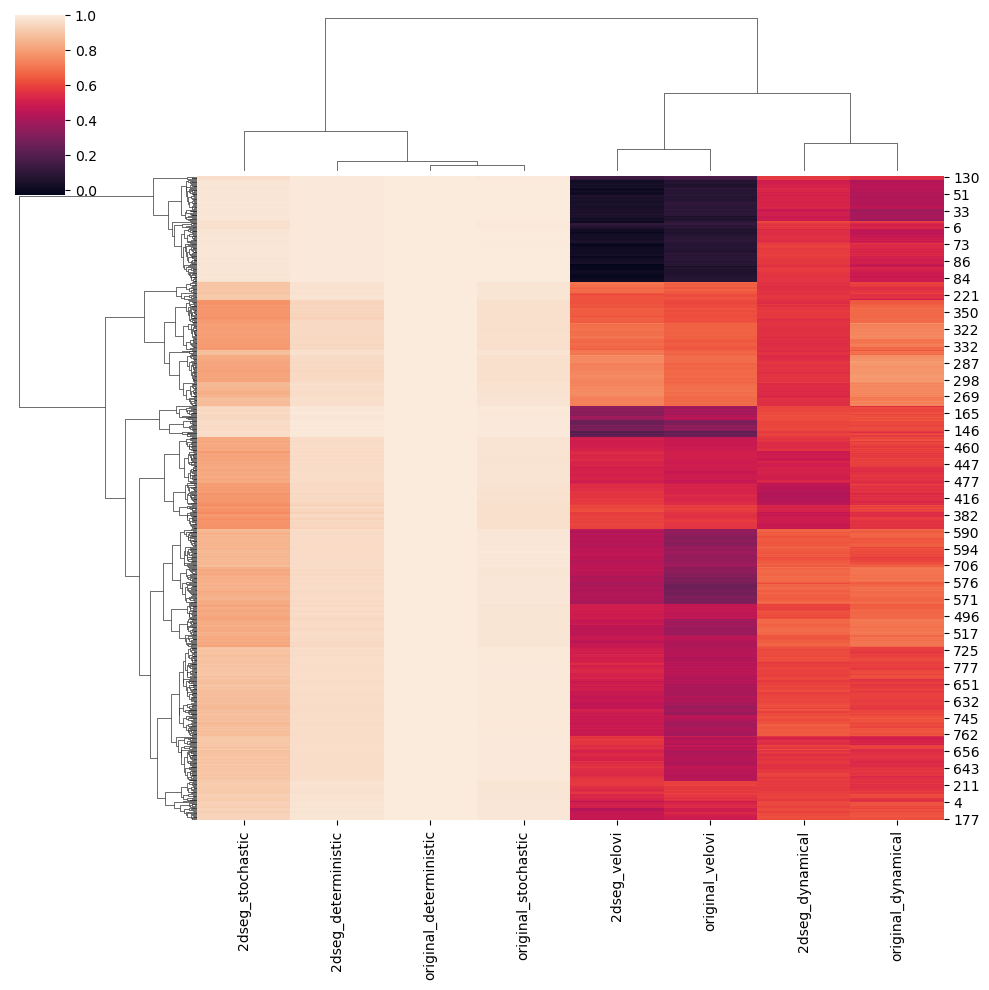

In [115]:
sns.clustermap(corr_cell['800']['original_deterministic'])

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

for obs_count in sorted(mean_corr_cell.keys()):
    corr_matrix = mean_corr_cell[obs_count]
    corr_matrix_numeric = corr_matrix.astype(float)
    
    g = sns.clustermap(
        corr_matrix_numeric,
        cmap='coolwarm',
        annot=True,
        vmin=-1,
        vmax=1,
        figsize=(8, 8)
    )
    g.fig.suptitle(f'Clustermap of Mean Correlations for {obs_count} Observations', y=1.05)
    plt.show()


NameError: name 'mean_corr_cell' is not defined

# Check the important genes 

In [83]:
for adata_name, adata in adata_dict.items():
    scv.tl.rank_velocity_genes(adata,groupby='leiden',min_corr=.3)

ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
   

In [117]:
dfs = scv.get_df(adata_dict['adata_n_c_800obs_300genes_dynamical'].uns['rank_velocity_genes']['names'])
dfs.head(5)

,0,1,2,3,4,5,6,7,8
0,148,214,228,285,206,298,108,197,298
1,231,173,298,104,215,131,211,108,267
2,183,159,158,82,119,206,197,213,153
3,293,203,288,16,188,232,227,290,206
4,192,16,110,247,18,288,213,167,84


In [122]:
dfn = scv.get_df(adata_dict['adata_n_c_800obs_300genes_2dseg_dynamical'].uns['rank_velocity_genes']['names'])
dfn.tail(5)

,0,1,2,3,4,5,6,7,8
95,129,107,111,248,105,265,137,299,221
96,298,219,17,284,123,107,1,174,20
97,106,19,40,250,27,129,190,153,38
98,220,251,163,203,50,240,251,56,106
99,287,163,140,40,149,161,44,33,158


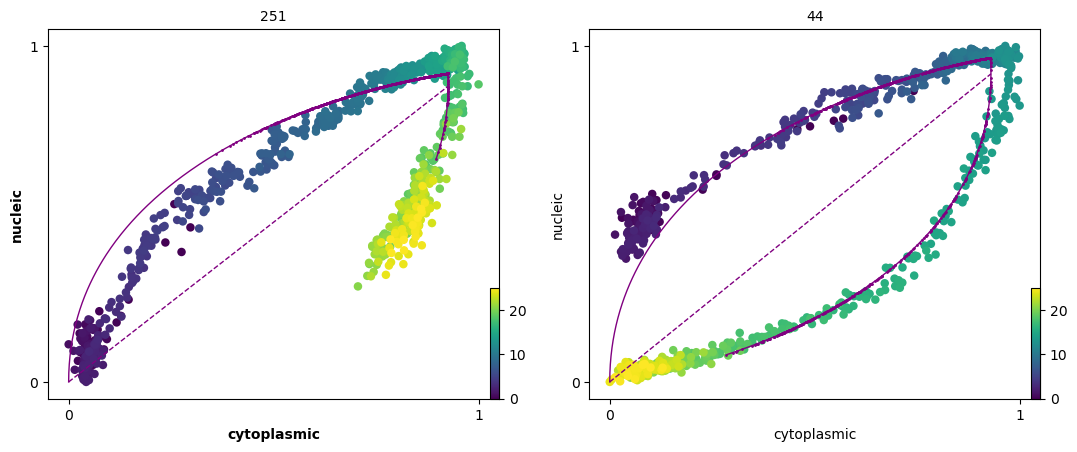

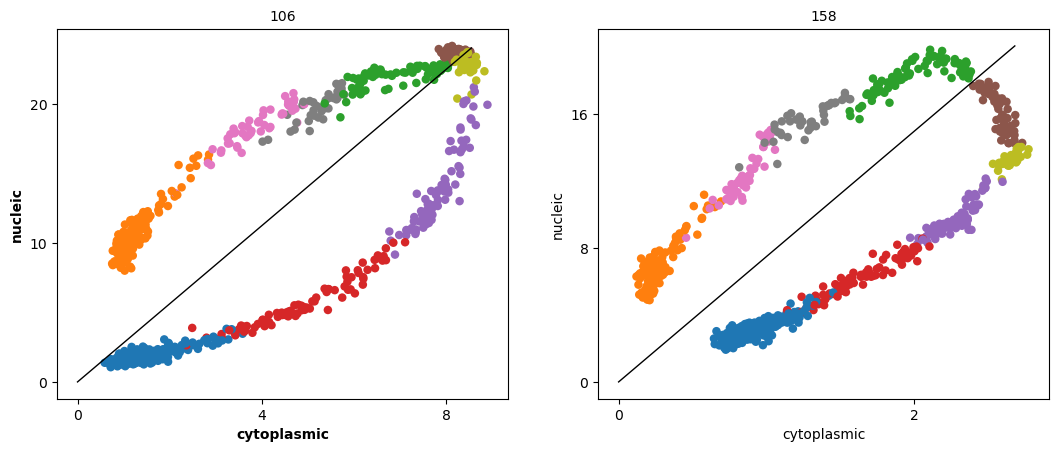

In [133]:
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_velovi'], dfn['6'].tail(2), xlabel='cytoplasmic',ylabel='nucleic', color='true_t')
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_deterministic'], dfn['8'].tail(2), xlabel='cytoplasmic',ylabel='nucleic', color= 'leiden')

### Compare all models

In [44]:
corr_by_cell = velocity_mean_correlation(adata_dict,mode='by_cell')
corr_by_gene = velocity_mean_correlation(adata_dict,mode='by_gene')

In [45]:
name_mapping = {}

# Define data type mapping
data_type_map = {
    'n_c': 'in situ',
    's_u': 'splicing'
}

# Loop over each name in the index (and columns)
for name in corr_by_cell.index:
    parts = name.split('_')
    # Extract data type (e.g., 'n_c' or 's_u')
    data_type = parts[1] + '_' + parts[2]
    data_type_label = data_type_map.get(data_type, data_type)
    
    # Extract velocity model (e.g., 'deterministic', 'stochastic', etc.)
    velocity_model = parts[5]
    # Capitalize the velocity model name
    velocity_model_label = velocity_model.capitalize()
    
    # Combine to form the new label
    new_label = f"{velocity_model_label} {data_type_label}"
    
    # Add to the mapping
    name_mapping[name] = new_label



In [75]:
# Rename the index and columns using the mapping
corr_by_cell = corr_by_cell.rename(index=name_mapping, columns=name_mapping)
corr_by_gene = corr_by_gene.rename(index=name_mapping, columns=name_mapping)

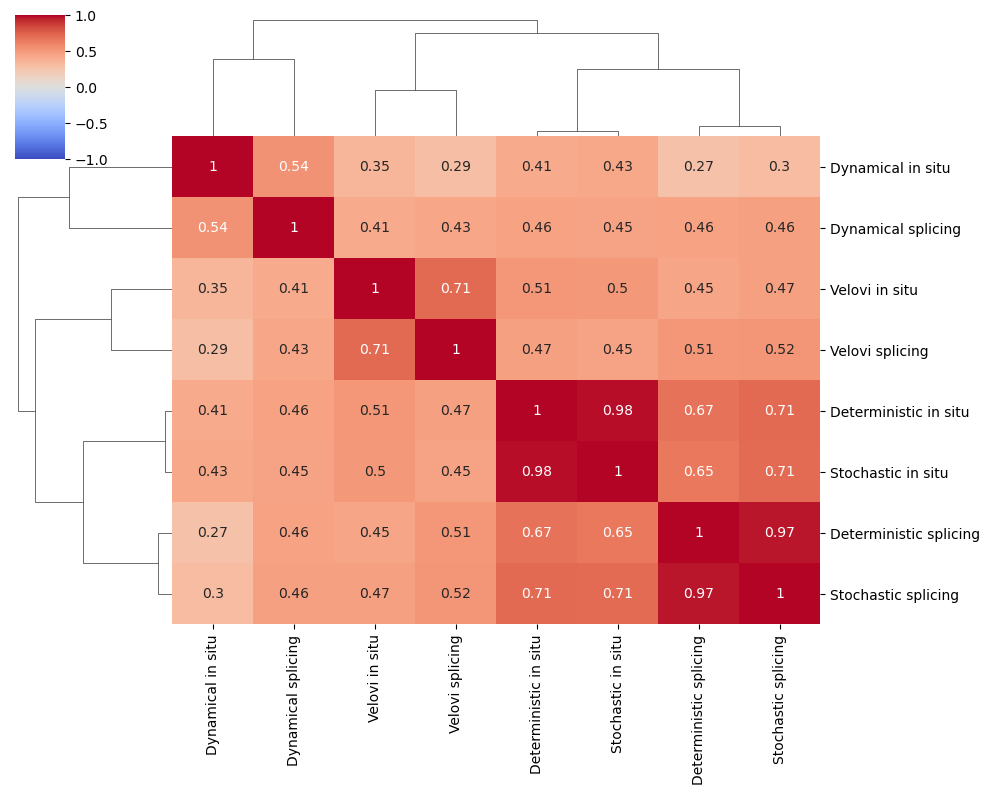

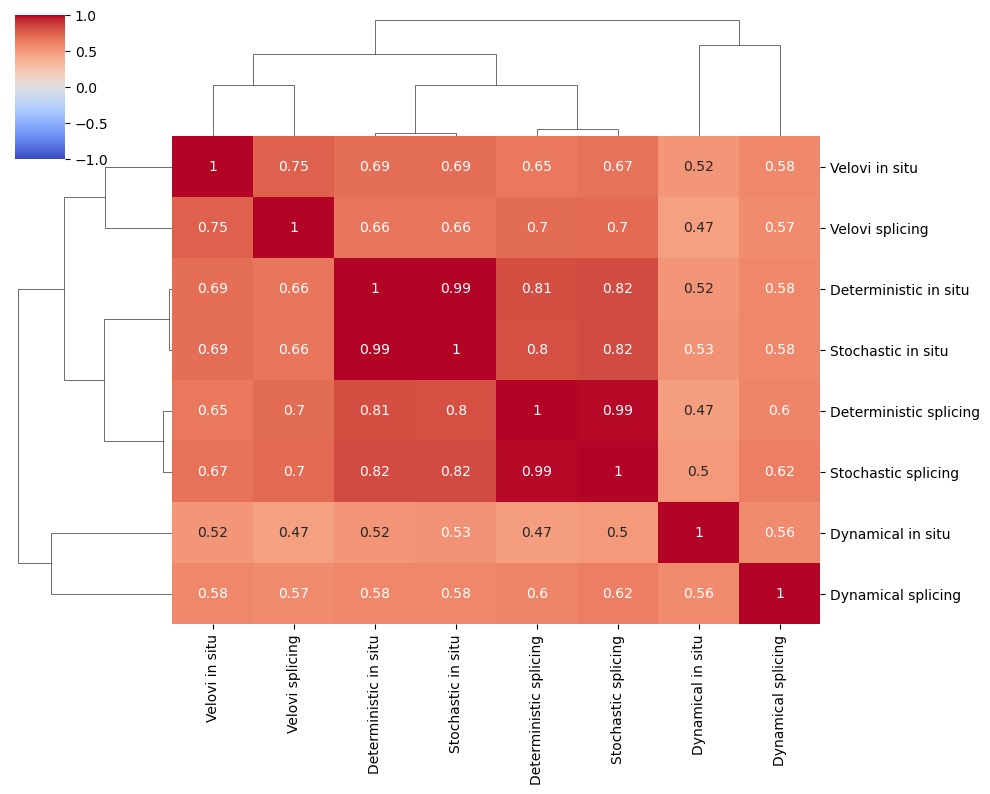

In [76]:
sns.clustermap(corr_by_cell, cmap='coolwarm', annot=True, figsize=(10, 8), vmin=-1, vmax=1)

sns.clustermap(corr_by_gene, cmap='coolwarm', annot=True, figsize=(10, 8), vmin=-1, vmax=1)

# Further plot for analysis- gene simulation 

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Your sorted data arrays
def plot_gene_counts(n_obs: None, n_var : None, gene : 0):
    adata = adata_dict[f'adata_n_c_{n_obs}obs_{n_var}genes_deterministic']
    unspliced = adata.layers['unspliced'][:,gene]- adata.layers['spliced_nuc'][:,gene] 
    spliced_nuc = adata.layers['spliced_nuc'][:,gene]
    spliced_cyto = adata.layers['spliced'][:,gene]

    t_max = adata.obs['true_t'].max()

    # Assuming the x-values are indices or known values
    x_values = np.arange(len(unspliced))
    scaling_factor = t_max / n_obs
    x_values_scaled = x_values * scaling_factor

    # Define a function for moving average smoothing
    def moving_average(y, window_size):
        return np.convolve(y, np.ones(window_size)/window_size, mode='valid')

    # Set the window size for smoothing
    window_size = 15  # Adjust the window size as needed

    # Calculate the moving averages for each dataset
    smooth_data1 = moving_average(unspliced, window_size)
    smooth_data2 = moving_average(spliced_nuc, window_size)
    smooth_data3 = moving_average(spliced_cyto, window_size)

    smooth_x_values = x_values[:len(smooth_data1)] + (window_size // 2)
    smooth_x_values_scaled = smooth_x_values * scaling_factor

    # Plot the smooth lines for each dataset using scaled x-values
    plt.plot(smooth_x_values_scaled, smooth_data1, color='blue', linewidth=2, label='unspliced')
    plt.plot(smooth_x_values_scaled, smooth_data2, color='red', linewidth=2, label='spliced nucleic')
    plt.plot(smooth_x_values_scaled, smooth_data3, color='green', linewidth=2, label='spliced cytoplasmic')


    true_t = adata.var['true_t_'][gene] 


    # Draw the vertical line using the scaled x-value
    plt.axvline(x=true_t, color='black', linestyle='--', linewidth=1, label='switch time')

    # Add labels and title
    plt.xlabel('Time')
    plt.ylabel('Abundances')
    plt.title('RNA abundances change over time')
    plt.legend(loc = 'upper right',fontsize = 8)
    plt.grid(True)

    # Display the plot
    plt.show()


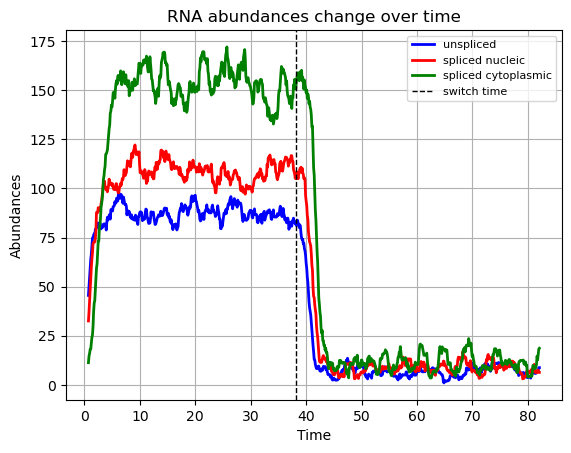

In [55]:
plot_gene_counts(n_obs=800,n_var=300,gene=0)

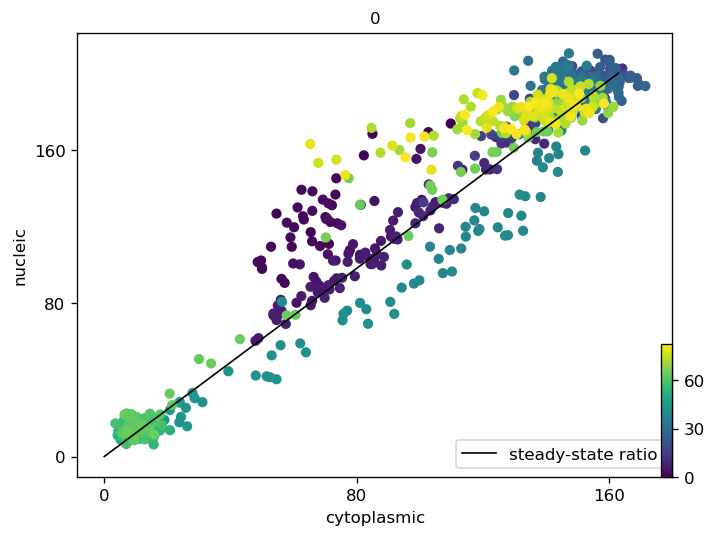

In [ ]:
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_deterministic'],color="true_t", basis=['0'], ncols=5, frameon=True,dpi=120, xlabel='cytoplasmic', ylabel='nucleic', vkey='velocity')

In [ ]:
54.159129	70.313750	1.904799	3.990005	3.548132	1.0	772	1.021699	1.021699	0.926665

In [227]:
70/3.5

20.0

In [226]:
70/4

17.5

In [225]:
70/1.9

36.8421052631579

In [9]:
adata = adata_dict['adata_n_c_800obs_300genes_dynamical']
adata_2 = adata_dict['adata_n_c_800obs_300genes_velovi']

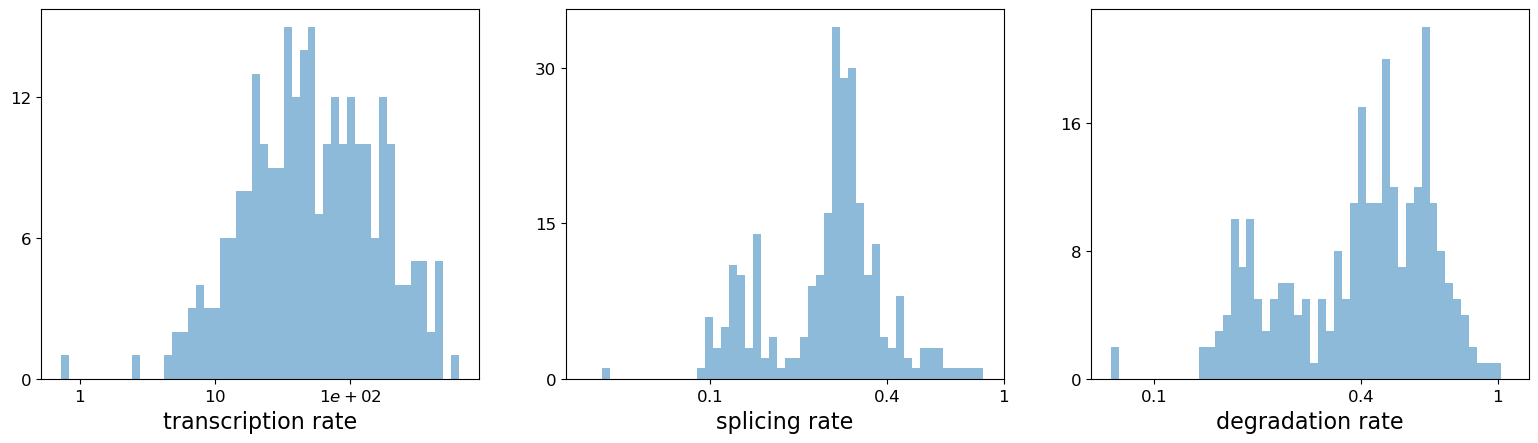

,fit_r2,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling,fit_std_u,fit_std_s,fit_likelihood,fit_u0,fit_s0,fit_pval_steady,fit_steady_u,fit_steady_s,fit_variance,fit_alignment_scaling
0,0.947685,78.892905,0.396832,0.476532,13.310665,0.571928,72.172874,56.786503,1.066159,0.0,0.0,0.498403,187.272808,150.313407,0.047913,1.982734
1,0.867178,226.230347,0.601453,0.765434,13.627937,0.629199,112.019257,84.121399,0.682976,0.0,0.0,0.498625,367.827794,283.013365,0.192942,1.189111
2,0.952033,81.563627,1.001864,0.834815,12.657267,0.396956,30.544258,34.625793,1.062409,0.0,0.0,0.497243,80.504823,93.171358,0.050733,1.131518
3,0.913156,8.187336,0.035167,0.483377,10.351687,8.599413,80.022118,4.652766,0.813359,0.0,0.0,0.492332,231.212267,13.562099,0.071543,1.736044
4,0.969630,16.473735,0.086666,0.321895,18.267079,5.378562,81.095314,17.854284,0.567693,0.0,0.0,0.496719,203.005373,43.855465,0.173006,2.419404


In [12]:
df = adata.var
df = df[(df['fit_likelihood'] > .1) & df['velocity_genes'] == True]
kwargs = dict(xscale='log', fontsize=16)
with scv.GridSpec(ncols=3) as pl:
    pl.hist(df['fit_alpha'], xlabel='transcription rate', **kwargs)
    pl.hist(df['fit_beta'] * df['fit_scaling'], xlabel='splicing rate', xticks=[.1, .4, 1], **kwargs)
    pl.hist(df['fit_gamma'], xlabel='degradation rate', xticks=[.1, .4, 1], **kwargs)

scv.get_df(adata, 'fit*', dropna=True).head()

In [13]:
df

,true_t_,true_alpha,true_beta,true_nu,true_gamma,true_scaling,n_cells,fit_r2,fit_alpha,fit_beta,...,fit_std_s,fit_likelihood,fit_u0,fit_s0,fit_pval_steady,fit_steady_u,fit_steady_s,fit_variance,fit_alignment_scaling,velocity_genes
0,38.232634,199.130635,2.229647,1.851729,1.291858,1.0,752,0.947685,78.892905,0.396832,...,56.786503,1.066159,0.0,0.0,0.498403,187.272808,150.313407,0.047913,1.982734,True
1,48.473325,219.261612,1.244513,1.104662,0.772268,1.0,767,0.867178,226.230347,0.601453,...,84.121399,0.682976,0.0,0.0,0.498625,367.827794,283.013365,0.192942,1.189111,True
2,41.504610,104.177984,2.128359,3.014790,1.103346,1.0,738,0.952033,81.563627,1.001864,...,34.625793,1.062409,0.0,0.0,0.497243,80.504823,93.171358,0.050733,1.131518,True
5,44.289003,435.872751,4.368890,1.182588,0.807082,1.0,759,0.889901,423.866123,0.897849,...,183.133484,1.025309,0.0,0.0,0.499393,447.346964,537.771665,0.053412,1.298691,True
6,31.303587,64.908867,1.635486,0.479241,2.160695,1.0,756,0.965912,8.462438,0.043273,...,11.159791,0.862175,0.0,0.0,0.495459,161.045004,28.115837,0.064980,4.092717,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,17.990758,126.678299,0.365851,0.494462,1.393540,1.0,748,0.899076,52.309879,0.087155,...,27.113899,0.743072,0.0,0.0,0.499216,442.499310,52.266061,0.093245,1.682057,True
296,10.190701,95.226863,1.714429,0.898292,1.139212,1.0,715,0.950541,40.916002,0.269592,...,23.913658,0.679478,0.0,0.0,0.499444,143.745445,67.213812,0.106659,1.660873,True
297,57.655704,182.487705,1.705067,2.087826,1.485469,1.0,777,0.857197,36.326702,0.174649,...,22.936205,0.287966,0.0,0.0,0.494352,188.492006,116.227097,0.698538,3.452644,True
298,64.590633,306.261010,1.994270,4.013386,2.293842,1.0,778,0.727462,39.601039,0.162066,...,20.992708,0.260761,0.0,0.0,0.490531,228.140158,132.364460,0.861057,3.803473,True


In [104]:
df_2 = scv.get_df(adata_2, 'fit*', dropna=True).head()

In [109]:
adata_2

AnnData object with n_obs × n_vars = 800 × 300
    obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'spearmans_score', 'velocity_score'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'leiden_colors', 'rank_velocity_genes'
    obsm: 'X_pca', 'X_umap', 'velocity_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'fit_t', 'latent_time_velovi', 'spliced', 'spliced_nuc', 'true_velocity', 'unspliced', 'variance_velocity', 'velocity'
    obsp: 'connectivities', 'distances'

In [108]:
df_2

,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling
0,0.285366,0.315427,0.319966,15.111290,1.0
1,0.324825,0.355882,0.375632,14.144192,1.0
2,0.340708,0.381818,0.372942,13.750994,1.0
3,0.303804,0.348542,0.334934,14.477716,1.0
4,0.319214,0.364773,0.362476,12.150274,1.0


In [101]:
df[['true_t_','fit_t_']]

,true_t_,fit_t_
0,38.232634,13.310665
1,48.473325,13.627937
2,41.504610,12.657267
5,44.289003,11.347119
6,31.303587,22.485876
...,...,...
295,17.990758,8.581597
296,10.190701,8.859769
297,57.655704,13.819764
298,64.590633,15.203607
